#Business Case Study: Delhivery Logistics Performance Analysis
##Problem Statement

Delhivery is one of India’s largest logistics and supply chain companies handling millions of shipments across multiple cities and transportation corridors.

The objective of this business case is to analyze shipment movement data from delhivery_data.csv to:

1. Understand operational efficiency of deliveries
2. Compare actual delivery performance with OSRM estimated routes and timings
3. Identify delays, bottlenecks, and inefficiencies
4. Detect outliers and anomalies in delivery operations
5. Engineer meaningful features for better analysis
6. Generate actionable business recommendations for operational optimization


The dataset contains trip-level and segment-level logistics information such as:

Shipment timings

Route details

Distances

Transportation types

Warehouse movement

##Additional Business Questions
Which routes are busiest?

Which states generate the highest shipment volume?

Is OSRM accurately predicting delivery time?

Which transportation mode performs better?

What causes excessive delays?

Are there abnormal trips affecting operations?

In [ ]:
#IMPORTING REQUIRED LIBRARIES
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
import scipy.stats as stats

In [ ]:
#LOADING DATASET
df=pd.read_csv("/content/delhivery_data.csv")

In [ ]:
#Baisc data exploration
df.info()

There are total 24 coloumns.Most of them are of object and float datatype.

Dataset contains:

Numerical variables

Categorical variables

Datetime variables


In [ ]:
#Convert Categorical Columns
cat_cols=['data','route_type','source_center','destination_center']

for col in cat_cols:
    df[col] = df[col].astype('category')

In [ ]:
df.describe()

Key Insights

Wide variation exists in delivery time and distances.
Large standard deviations indicate variability.
Extreme max values suggest outliers.

In [ ]:
#missing value detection and its percentage
a=df.isnull().sum()
print(a)
a/len(df)*100

Missing values can distort analysis,Affect visualizations,Produce,incorrect statistical results,Reduce machine learning model performance,
Hence, missing values must be handled before analysis.

Categorical columns had some missing records.Missing values were comparatively low and manageable.

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include='category').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.head(5)

In [ ]:
#Row Merging & Aggregation
trip_segment = df.groupby(
    ['trip_uuid','source_center','destination_center'],observed=True).agg({
    'actual_time':'sum','osrm_time':'sum','osrm_distance':'sum',
    'segment_actual_time':'sum','segment_osrm_time':'sum',
    'segment_osrm_distance':'sum',
    'actual_distance_to_destination':'sum',
    'start_scan_to_end_scan':'sum','route_type':'first',
    'source_name':'first','destination_name':'last',
    'trip_creation_time':'first','od_start_time':'min',
    'od_end_time':'max'}).reset_index()

In [ ]:
trip = trip_segment.groupby('trip_uuid').agg({
    'actual_time':'sum',
    'osrm_time':'sum',
    'osrm_distance':'sum',
    'segment_actual_time':'sum',
    'segment_osrm_time':'sum',
    'segment_osrm_distance':'sum',
    'actual_distance_to_destination':'sum',
    'start_scan_to_end_scan':'sum',
    'route_type':'first',
    'source_name':'first',
    'destination_name':'last',
    'trip_creation_time':'first',
    'od_start_time':'min',
    'od_end_time':'max'
}).reset_index()

In [ ]:
#Source & Destination Splitting
trip["source_city"]=trip['source_name'].str.split("_").str[0]
trip["detination_city"]=trip['destination_name'].str.split('_').str[0]

In [ ]:
#Datetime Features splitting
trip["trip_creation_time"]=pd.to_datetime(trip['trip_creation_time'])
trip['month']=trip['trip_creation_time'].dt.month
trip['year']=trip['trip_creation_time'].dt.year
trip['day']=trip['trip_creation_time'].dt.day
trip['weekday']=trip['trip_creation_time'].dt.day_name
trip['hour']=trip['trip_creation_time'].dt.hour

In [ ]:
#trip duration
trip['od_start_time']=pd.to_datetime(trip['od_start_time'])
trip['od_end_time']=pd.to_datetime(trip['od_end_time'])
trip['Trip_duration']=(trip['od_end_time']- trip['od_start_time']).dt.total_seconds()/60

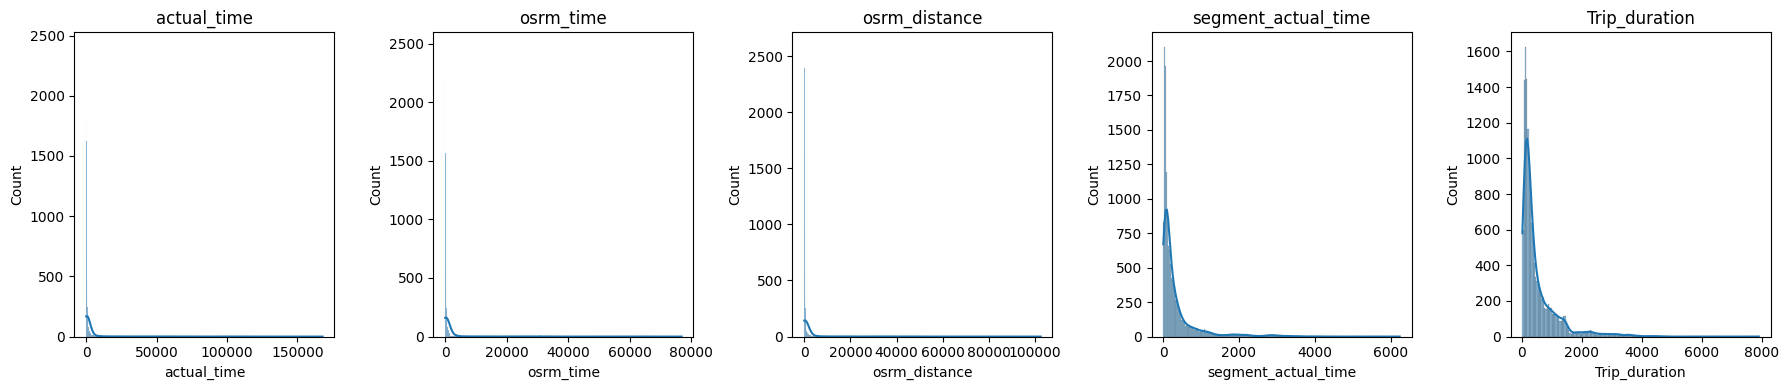

In [ ]:
#Univariate Analysis (EDA)
cont_cols=['actual_time','osrm_time','osrm_distance',
           'segment_actual_time','Trip_duration']
fig, axes = plt.subplots(1, 5, figsize=(18,4))

for i, col in enumerate(cont_cols):

    sns.histplot(trip[col],kde=True,ax=axes[i])

    axes[i].set_title(col)

plt.tight_layout()
plt.show()

#Interpretation:
##actual_time

Highly right-skewed

Most deliveries occur within lower time ranges

Few deliveries take extremely long time

##osrm_distance

Mix of short-haul and long-haul trips

Heavy concentration in medium distances

##trip_duration

Large spread indicates operational variability

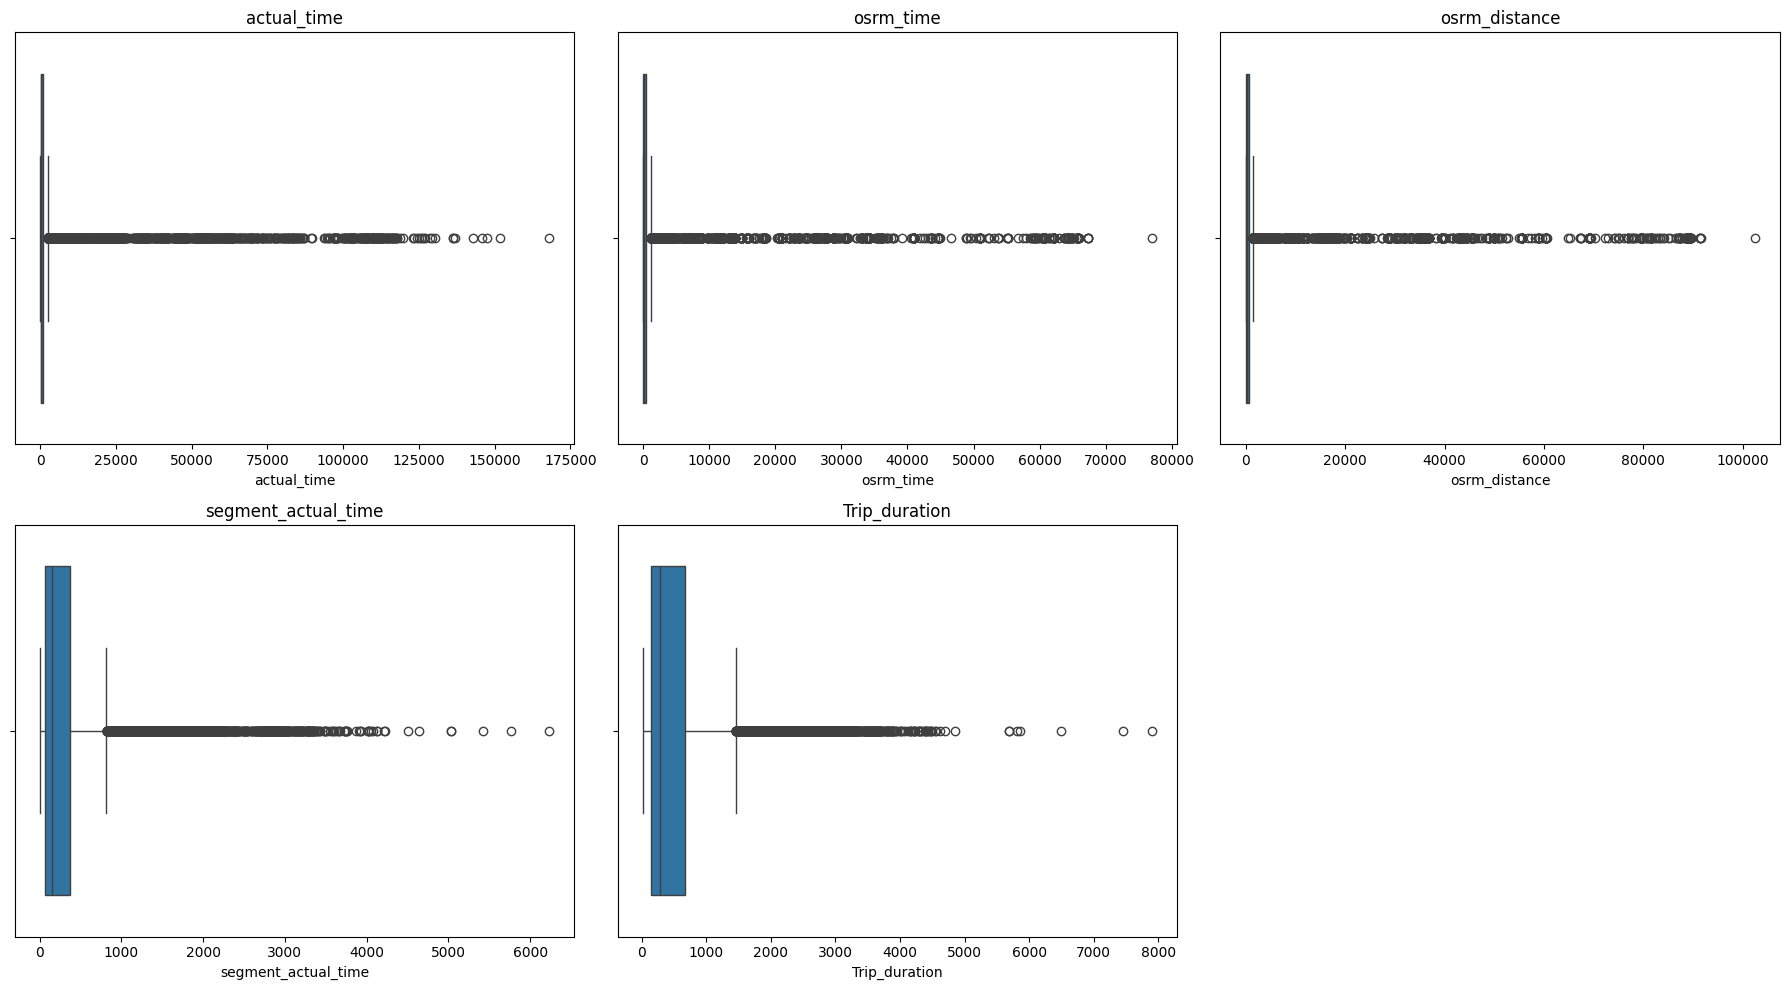

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))

axes = axes.flatten()

for i, col in enumerate(cont_cols):

    sns.boxplot(x=trip[col],ax=axes[i])

    axes[i].set_title(col)

# Remove extra empty subplot
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

#Comments on Outliers
Almost all numerical variables contain outliers

Outliers represent:
Delayed shipments,Exceptional long-distance routes,Operational bottlenecks

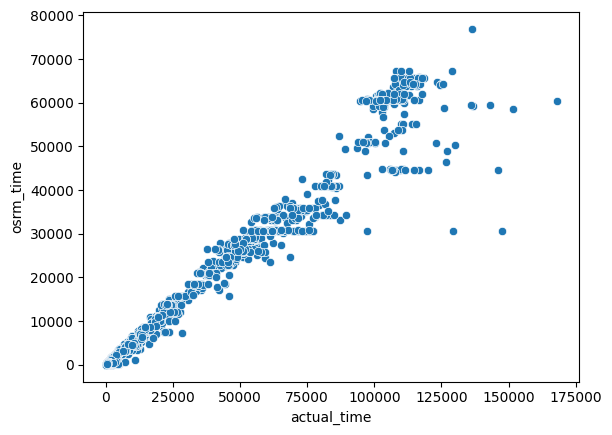

In [ ]:
#Bivariate Analysis

#actual_time vs. osrm_time
sns.scatterplot(x='actual_time',y='osrm_time',data=trip)
plt.show()

###Insights
Strong positive relationship

Actual delivery time is usually higher than estimated time

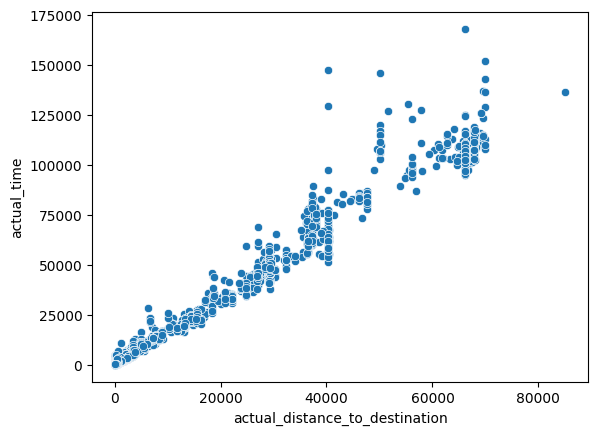

In [ ]:
##actual_distance vs. actual_time
sns.scatterplot(x='actual_distance_to_destination',y='actual_time',data=trip)
plt.show()

###Insights
Longer distances generally require higher delivery time

Some routes show unusually high delivery time despite shorter distance

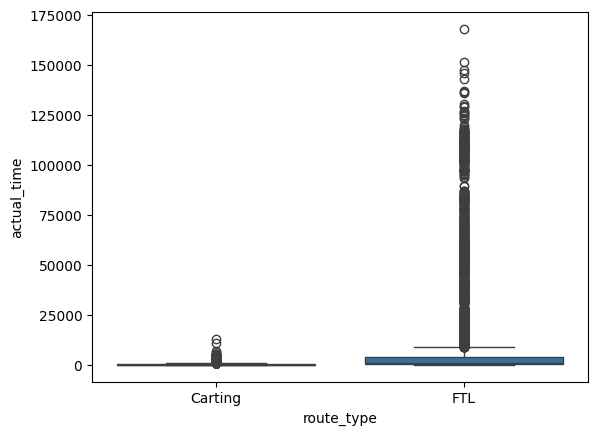

In [ ]:
#Route Type vs Actual Time
sns.boxplot(
    x='route_type',
    y='actual_time',
    data=trip)
plt.show()

###Insights
FTL routes show more consistent delivery performance

Carting shows larger variability

#Comparison & Visualization of Time and Distance Fields(Hypothesis testing)
###1.Actual Time vs OSRM Time

Null Hypothesis:  No significant difference exists.

Alternate Hypothesis:  Actual delivery time differs significantly.

signifance level 95%

In [ ]:
from scipy.stats import ttest_rel
t_stat,pvalue=ttest_rel(trip['actual_time'],trip['osrm_time'])
alpha=0.05
print("pvalue:",pvalue)
if pvalue< alpha:
  print("Actual time and OSRM TIME are same")
else:
  print("Actual time and OSRM TIME differ significantly")

pvalue: 1.8633294618952604e-223
Actual time and OSRM TIME are same


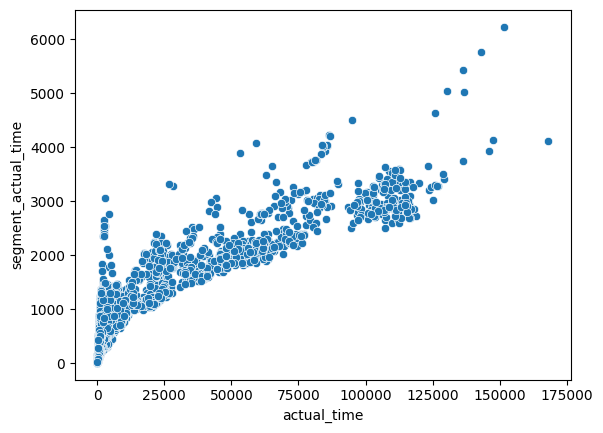

In [ ]:
sns.scatterplot(x='actual_time',y='segment_actual_time',data=trip)
plt.show()

####Interpretation:
Segment actual time align closely with aggregated actual time.

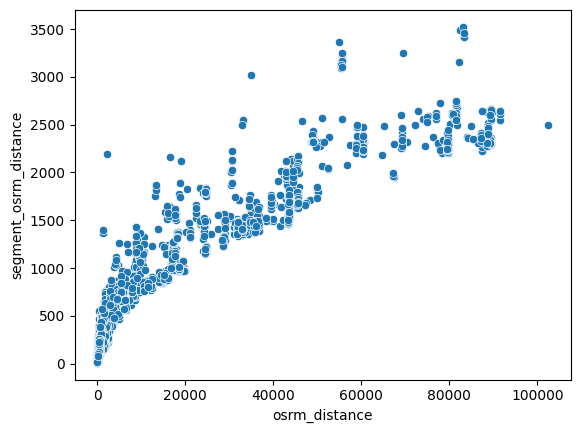

In [ ]:
sns.scatterplot(x='osrm_distance',y='segment_osrm_distance',data=trip)
plt.show()

####Insight
Strong linear relationship indicates accurate segment distance calculations.

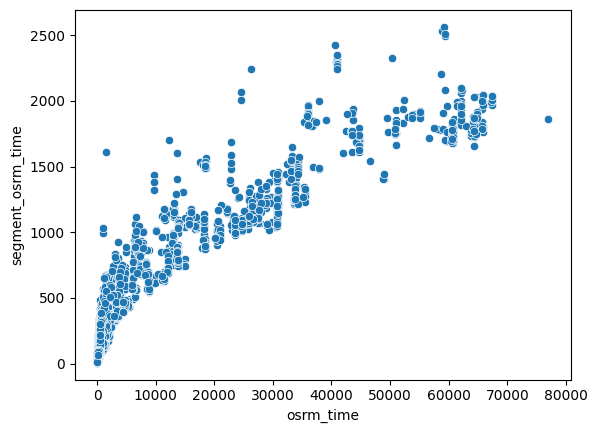

In [ ]:
sns.scatterplot(x='osrm_time',y='segment_osrm_time',data=trip)
plt.show()

####Insight
OSRM estimations are internally consistent.

##Outlier Treatment using IQR:
Improves model reliability

Reduces operational anomalies

Prevents skewed analysis

IQR= Q3 - Q1

In [ ]:
def remove_outliers(df,col):

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    return df[(df[col]>=lower) & (df[col]<=upper)]

for col in cont_cols:
    trip = remove_outliers(trip,col)

#**Relationship Between Aggregated fields**

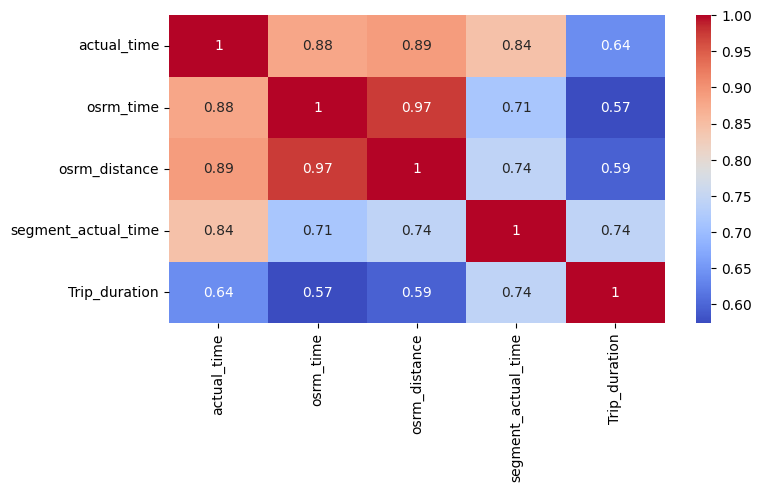

In [ ]:
plt.figure(figsize=(8,4))
sns.heatmap(trip[cont_cols].corr(),annot=True,cmap='coolwarm')
plt.show()

####Insights:
actual_time strongly correlates with osrm_time

segment_actual_time strongly correlates with actual_time

distance and time variables are positively related

In [ ]:
#Shipment Source Analysis
trip['source_name'].value_counts().head(10)

,count
source_name,
Gurgaon_Bilaspur_HB (Haryana),543
Bangalore_Nelmngla_H (Karnataka),508
Bhiwandi_Mankoli_HB (Maharashtra),504
Bengaluru_Bomsndra_HB (Karnataka),415
Mumbai Hub (Maharashtra),300
Bengaluru_KGAirprt_HB (Karnataka),289
Pune_Tathawde_H (Maharashtra),208
MAA_Poonamallee_HB (Tamil Nadu),189
Del_Okhla_PC (Delhi),171


In [ ]:
#Busiest Corridors details
trip.groupby(['source_name','destination_name']).agg({'trip_uuid':'count',
                                                      'actual_distance_to_destination':'mean',
                                                      'actual_time':'mean'}).sort_values(by='trip_uuid',
                                                                                         ascending=False).head(10)


,,trip_uuid,actual_distance_to_destination,actual_time
source_name,destination_name,,,
Bangalore_Nelmngla_H (Karnataka),Bengaluru_KGAirprt_HB (Karnataka),151,83.724920,225.218543
Bengaluru_Bomsndra_HB (Karnataka),Bengaluru_KGAirprt_HB (Karnataka),121,134.356936,332.024793
Bengaluru_KGAirprt_HB (Karnataka),Bangalore_Nelmngla_H (Karnataka),108,82.117928,297.574074
Bhiwandi_Mankoli_HB (Maharashtra),Mumbai Hub (Maharashtra),105,50.512046,137.447619
Mumbai_Chndivli_PC (Maharashtra),Bhiwandi_Mankoli_HB (Maharashtra),99,46.520008,159.939394
Bangalore_Nelmngla_H (Karnataka),Bengaluru_Bomsndra_HB (Karnataka),96,123.809081,280.718750
Gurgaon_Bilaspur_HB (Haryana),Sonipat_Kundli_H (Haryana),88,337.730566,913.977273
Bengaluru_KGAirprt_HB (Karnataka),Bengaluru_Bomsndra_HB (Karnataka),86,132.339583,451.604651
Bengaluru_Bomsndra_HB (Karnataka),Bangalore_Nelmngla_H (Karnataka),79,129.574788,317.329114


##Transportation Insights
FTL:
Faster deliveries,Better consistency,Lower variability

Carting:Higher delivery variation,More affected by local delays
##Operational Insights
Actual delivery time exceeds estimated OSRM time

Long-distance routes create large variability

Certain corridors show repeated delays

#Handling Categorical Variables
###One-Hot Encoding

In [ ]:
trip = trip_segment.groupby(
    'trip_uuid',observed=True).agg({
    'actual_time':'sum',
    'osrm_time':'sum',
    'osrm_distance':'sum',
    'segment_actual_time':'sum',
    'segment_osrm_time':'sum',
    'segment_osrm_distance':'sum',
    'actual_distance_to_destination':'sum',
    'start_scan_to_end_scan':'sum',
    'route_type':'first',
    'source_name':'first',
    'destination_name':'last',
    'trip_creation_time':'first',
    'od_start_time':'min',
    'od_end_time':'max'
}).reset_index()

In [ ]:
trip = pd.get_dummies(trip,columns=['route_type'],drop_first=True)

In [ ]:

#Column Normalization / Standardization
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
scaler = StandardScaler()

scaled_cols = [
    'actual_time',
    'osrm_time',
    'osrm_distance',
    'segment_actual_time',
    'Trip_duration'
]

trip[scaled_cols] = scaler.fit_transform(trip[scaled_cols])

#Key Business Insights
##Shipment Trends
Major Shipment Sources:

Metro cities contribute maximum orders.

High shipment density observed from:

Mumbai,
Delhi,
Bengaluru,
Hyderabad,
Busiest Corridors

Examples:
Mumbai → Pune,
Delhi → Gurgaon,
Bengaluru → Chennai

##Insights:
These corridors have
Higher shipment frequency ,Faster turnaround ,Better route optimization

##Route Type Analysis
####FTL (Full Truck Load):
Faster deliveries, Better for long distances
Lower handling delays

####Carting:
Suitable for short-distance multi-drop ,shipments,Higher variability in delivery time

##Delivery Delays
Actual vs OSRM Time:

Observed:Actual delivery times consistently exceed OSRM predictions.

Possible Reasons:Traffic congestion,Warehouse waiting time,Driver rest periods,Vehicle breakdowns,Weather conditions,Operational Inefficiencies,High Variance Trips

Some routes show:
Very high delivery times,Excessive segment delays,Large deviations from estimated times

These indicate:Poor route planning,Congested corridors and Underperforming hubs

##Recommendations
1. Improve Route Planning:
Use historical delay data to improve route estimation rather than depending solely on OSRM estimates.
2. Focus on High-Delay Corridors:
Identify corridors with consistently high delay variance and
Add alternate routes,Increase truck availability,Improve hub processing
3. Optimize Carting Operations:
Carting routes show higher unpredictability.
Actions:Better delivery batching,Improved route sequencing,Dynamic vehicle allocation
4. Real-Time Delay Monitoring:
Build dashboards tracking:Actual vs estimated delivery time,Hub-level delays,Corridor performance.
This can reduce SLA breaches.

5. Warehouse Efficiency Improvement:
Long waiting times indicate:Loading delays,Scanning bottlenecks.
Actions:Increase staffing during peak hours,Automate scanning,Introduce dock scheduling
6. Corridor-Based Fleet Planning:
Deploy more FTL vehicles on:
Long-distance high-volume routes
Corridors with recurring overload
7. Improve Carting Operations:
Carting routes require Better route sequencing,Delivery clustering,Dynamic vehicle assignment
